# When Weather Changes the City
## Wrangling NYC 311 service requests with Central Park weather data

New York changes with the weather, and the calls residents make to 311 change with it. I use three complete years of city service-request data and daily NOAA observations to measure how cold, heat, and rain reshape the volume and mix of complaints across the five boroughs.

## Project map

1. Gather two related datasets with different methods
2. Assess two quality issues and two tidiness issues
3. Clean, validate, combine, and store the data
4. Answer the research question with exploratory analysis
5. Reflect on limitations and next steps

In [1]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/cleaned")
FIGURES_DIR = Path("figures")
for directory in (RAW_DIR, CLEAN_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ANALYSIS_START = "2022-01-01"
ANALYSIS_END = "2024-12-31"

## 1. Gather data

### 1.1 Problem statement

I want to understand how daily temperature and precipitation affect the number and type of NYC 311 complaints, and whether the response is similar across boroughs. I combine NYC Open Data service-request counts with NOAA observations from Central Park for 2022–2024, focusing on five complaint types that plausibly respond to weather: heat and hot water, street noise, street conditions, sewer problems, and air quality.

### 1.2 Dataset 1 — NYC 311 Service Requests

**Type:** CSV returned by a public API  
**Method:** API access through the NYC Open Data Socrata endpoint  
**Source:** [311 Service Requests from 2010 to Present](https://data.cityofnewyork.us/resource/erm2-nwe9)

I chose 311 data because it records how residents experience city conditions in near real time. I request daily counts by complaint type and borough for a fixed three-year window; `request_date` is the day of the request, `complaint_type` identifies the issue, `borough` locates it, and `request_count` records how many requests occurred in that group.

In [2]:
# The API query is kept here so the gathering process is fully reproducible.
NYC_API_URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"
NYC_RAW_PATH = RAW_DIR / "nyc_311_weather_complaints_2022_2024_raw.csv"
COMPLAINT_TYPES = [
    "HEAT/HOT WATER",
    "Noise - Street/Sidewalk",
    "Street Condition",
    "Sewer",
    "Air Quality",
]


def gather_311_data():
    frames = []
    quoted_types = ", ".join(f"'{value}'" for value in COMPLAINT_TYPES)

    for year in (2022, 2023, 2024):
        params = {
            "$select": (
                "date_trunc_ymd(created_date) as request_date, "
                "complaint_type, borough, count(*) as request_count"
            ),
            "$where": (
                f"created_date >= '{year}-01-01T00:00:00.000' AND "
                f"created_date < '{year + 1}-01-01T00:00:00.000' AND "
                f"complaint_type IN ({quoted_types})"
            ),
            "$group": "date_trunc_ymd(created_date), complaint_type, borough",
            "$order": "request_date, complaint_type, borough",
            "$limit": 50000,
        }
        response = requests.get(NYC_API_URL, params=params, timeout=180)
        response.raise_for_status()
        frames.append(pd.read_csv(BytesIO(response.content)))

    result = pd.concat(frames, ignore_index=True)
    result.to_csv(NYC_RAW_PATH, index=False)
    return result


if NYC_RAW_PATH.exists():
    service_requests = pd.read_csv(NYC_RAW_PATH)
    gathering_status = "Loaded the stored raw API result"
else:
    service_requests = gather_311_data()
    gathering_status = "Downloaded fresh data from the NYC Open Data API"

print(gathering_status)
print(f"Rows: {len(service_requests):,} | Columns: {service_requests.shape[1]}")
service_requests.head()

Loaded the stored raw API result
Rows: 26,631 | Columns: 4


,request_date,complaint_type,borough,request_count
0,2022-01-01T00:00:00.000,Air Quality,MANHATTAN,5
1,2022-01-01T00:00:00.000,Air Quality,QUEENS,2
2,2022-01-01T00:00:00.000,HEAT/HOT WATER,BRONX,164
3,2022-01-01T00:00:00.000,HEAT/HOT WATER,BROOKLYN,114
4,2022-01-01T00:00:00.000,HEAT/HOT WATER,MANHATTAN,114


### Dataset 2 — NOAA Central Park Daily Weather

**Type:** CSV file  
**Method:** Manual file download  
**Source:** [NOAA GHCN-Daily station USW00094728](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00094728.csv)

I downloaded the complete Central Park station record because it is a long-running, official daily series located within NYC. The analysis uses `DATE`, precipitation (`PRCP`), snowfall (`SNOW`), maximum temperature (`TMAX`), minimum temperature (`TMIN`), and NOAA's associated measurement attributes; the complete raw file has far more than 500 observations.

In [3]:
WEATHER_RAW_PATH = RAW_DIR / "central_park_weather_daily_raw.csv"
if not WEATHER_RAW_PATH.exists():
    raise FileNotFoundError(
        "Download the NOAA Central Park CSV from the source link above and save it as "
        f"{WEATHER_RAW_PATH}."
    )

weather = pd.read_csv(WEATHER_RAW_PATH, low_memory=False)
print(f"Rows: {len(weather):,} | Columns: {weather.shape[1]}")
print(f"Coverage: {weather['DATE'].min()} to {weather['DATE'].max()}")
weather[["STATION", "DATE", "PRCP", "PRCP_ATTRIBUTES", "SNOW", "TMAX", "TMIN"]].head()

Rows: 57,540 | Columns: 124
Coverage: 1869-01-01 to 2026-07-16


,STATION,DATE,PRCP,PRCP_ATTRIBUTES,SNOW,TMAX,TMIN
0,USW00094728,1869-01-01,191,",,Z,",229.00,-17.00,-72.00
1,USW00094728,1869-01-02,8,",,Z,null",0.00,-28.00,-61.00
2,USW00094728,1869-01-03,0,"T,,Z,null",0.00,17.00,-28.00
3,USW00094728,1869-01-04,46,",,Z,null",0.00,28.00,11.00
4,USW00094728,1869-01-05,13,",,Z,null",0.00,61.00,28.00


Both datasets comfortably exceed the minimum size: the API result contains daily borough/category observations, while the NOAA source contains more than a century of daily weather measurements. I preserve both files in `data/raw` before making any changes.

In [4]:
dataset_inventory = pd.DataFrame(
    {
        "dataset": ["NYC 311", "NOAA Central Park weather"],
        "rows": [len(service_requests), len(weather)],
        "columns": [service_requests.shape[1], weather.shape[1]],
        "gathering_method": ["API access", "Manual CSV download"],
    }
)
dataset_inventory

,dataset,rows,columns,gathering_method
0,NYC 311,26631,4,API access
1,NOAA Central Park weather,57540,124,Manual CSV download


## 2. Assess data

I use visual inspection to see the shape of each problem and programmatic checks to measure its extent. The four issues below are real data quality or structure problems—not feature engineering choices.

### Quality issue 1 — Unspecified boroughs in the 311 data

Because one part of the question compares boroughs, rows labeled `Unspecified` cannot be assigned to a valid borough. Looking at examples confirms the label is present, while a frequency check measures how much data it affects.

In [5]:
# Visual assessment
service_requests.loc[
    service_requests["borough"].eq("Unspecified"),
    ["request_date", "complaint_type", "borough", "request_count"],
].head(8)

,request_date,complaint_type,borough,request_count
63,2022-01-03T00:00:00.000,Sewer,Unspecified,1
91,2022-01-04T00:00:00.000,Street Condition,Unspecified,1
158,2022-01-07T00:00:00.000,Sewer,Unspecified,1
283,2022-01-12T00:00:00.000,Street Condition,Unspecified,1
331,2022-01-14T00:00:00.000,Street Condition,Unspecified,1
399,2022-01-17T00:00:00.000,Sewer,Unspecified,1
405,2022-01-17T00:00:00.000,Street Condition,Unspecified,1
425,2022-01-18T00:00:00.000,Sewer,Unspecified,1


In [6]:
# Programmatic assessment
borough_check = service_requests["borough"].value_counts(dropna=False).rename("rows")
display(borough_check.to_frame())
unspecified_rows = service_requests["borough"].eq("Unspecified").sum()
print(f"Unspecified rows: {unspecified_rows:,} ({unspecified_rows / len(service_requests):.2%})")

,rows
borough,
BROOKLYN,5463
QUEENS,5459
MANHATTAN,5424
BRONX,5241
STATEN ISLAND,4689
Unspecified,355


Unspecified rows: 355 (1.33%)


**Issue and justification:** `Unspecified` is an invalid borough for borough-level comparison. Frequency counts are appropriate because they expose both unexpected categories and their scale; the 355 affected aggregate rows are a small share of the data and cannot be reliably reassigned.

### Quality issue 2 — Trace precipitation is numerically recorded as zero

NOAA uses `T` in the precipitation attribute field when rain was detected but was too small to measure at the dataset's precision. Treating those observations as perfectly dry would understate precipitation and mix trace-rain days into the dry-day baseline.

In [7]:
# Visual assessment: zero-valued precipitation with a trace flag
trace_weather = weather.loc[
    weather["PRCP_ATTRIBUTES"].str.startswith("T", na=False),
    ["DATE", "PRCP", "PRCP_ATTRIBUTES", "TMAX", "TMIN"],
]
trace_weather.head(8)

,DATE,PRCP,PRCP_ATTRIBUTES,TMAX,TMIN
2,1869-01-03,0,"T,,Z,null",17.00,-28.00
10,1869-01-11,0,"T,,Z,null",6.00,-11.00
16,1869-01-17,0,"T,,Z,null",17.00,-17.00
17,1869-01-18,0,"T,,Z,null",-17.00,-33.00
19,1869-01-20,0,"T,,Z,null",28.00,-11.00
28,1869-01-29,0,"T,,Z,null",89.00,-11.00
33,1869-02-03,0,"T,,Z,null",22.00,17.00
35,1869-02-05,0,"T,,Z,null",-33.00,-56.00


In [8]:
# Programmatic assessment within the analysis window
weather_dates = pd.to_datetime(weather["DATE"])
analysis_weather_mask = weather_dates.between(ANALYSIS_START, ANALYSIS_END)
trace_mask = weather["PRCP_ATTRIBUTES"].str.startswith("T", na=False)
print(f"Trace-precipitation days: {(analysis_weather_mask & trace_mask).sum():,}")
print("Raw PRCP values on those days:")
display(weather.loc[analysis_weather_mask & trace_mask, "PRCP"].value_counts().to_frame())

Trace-precipitation days: 118
Raw PRCP values on those days:


,count
PRCP,
0,118


**Issue and justification:** The numeric value and its flag disagree semantically: zero means dry, while `T` means precipitation occurred. Checking the flag and numeric field together is necessary because looking at `PRCP` alone cannot reveal the problem; 118 days in the analysis window are affected.

### Tidiness issue 1 — NOAA attributes combine four variables in one column

`PRCP_ATTRIBUTES` contains a measurement flag, quality flag, source flag, and observation time separated by commas. These are separate variables packed into one field, violating the rule that each variable should have its own column.

In [9]:
# Visual assessment
weather.loc[analysis_weather_mask, ["DATE", "PRCP", "PRCP_ATTRIBUTES"]].head(10)

,DATE,PRCP,PRCP_ATTRIBUTES
55882,2022-01-01,201,",,W,2400"
55883,2022-01-02,10,",,W,2400"
55884,2022-01-03,0,",,W,2400"
55885,2022-01-04,0,",,W,2400"
55886,2022-01-05,58,",,W,2400"
55887,2022-01-06,0,",,W,2400"
55888,2022-01-07,97,",,W,2400"
55889,2022-01-08,0,",,W,2400"
55890,2022-01-09,25,",,W,2400"
55891,2022-01-10,0,",,W,2400"


In [10]:
# Programmatic assessment
attribute_parts = weather.loc[analysis_weather_mask, "PRCP_ATTRIBUTES"].str.split(",", expand=True)
print(f"Components found: {attribute_parts.shape[1]}")
attribute_parts.columns = ["measurement_flag", "quality_flag", "source_flag", "observation_time"]
attribute_parts.head()

Components found: 4


,measurement_flag,quality_flag,source_flag,observation_time
55882,,,W,2400
55883,,,W,2400
55884,,,W,2400
55885,,,W,2400
55886,,,W,2400


**Issue and justification:** Splitting the strings is the right assessment because it verifies the delimiter structure instead of assuming it from a few examples. Every row exposes four positions, so the fields can be separated consistently during cleaning.

### Tidiness issue 2 — One daily observation is split across two tables

The complaint counts and weather measurements describe the same city-day but live in separate datasets. Before analysis, they need a shared date key and a controlled many-to-one merge so every complaint group receives exactly one weather observation.

In [11]:
# Visual assessment
display(service_requests[["request_date", "complaint_type", "borough", "request_count"]].head(3))
display(weather.loc[analysis_weather_mask, ["DATE", "PRCP", "TMAX", "TMIN"]].head(3))

,request_date,complaint_type,borough,request_count
0,2022-01-01T00:00:00.000,Air Quality,MANHATTAN,5
1,2022-01-01T00:00:00.000,Air Quality,QUEENS,2
2,2022-01-01T00:00:00.000,HEAT/HOT WATER,BRONX,164


,DATE,PRCP,TMAX,TMIN
55882,2022-01-01,201,133.00,100.00
55883,2022-01-02,10,150.00,28.00
55884,2022-01-03,0,28.00,-55.00


In [12]:
# Programmatic assessment
service_dates = pd.to_datetime(service_requests["request_date"]).dt.normalize()
weather_analysis_dates = pd.to_datetime(weather.loc[analysis_weather_mask, "DATE"])
print(f"311 unique dates: {service_dates.nunique():,}")
print(f"Weather unique dates: {weather_analysis_dates.nunique():,}")
print(f"Overlapping dates: {len(set(service_dates) & set(weather_analysis_dates)):,}")
print(f"Duplicate weather dates: {weather_analysis_dates.duplicated().sum():,}")

311 unique dates: 1,096
Weather unique dates: 1,096
Overlapping dates: 1,096
Duplicate weather dates: 0


**Issue and justification:** Date-key counts test whether a merge is feasible and whether weather is unique at the intended daily grain. All 1,096 dates overlap and NOAA has no duplicate dates, supporting a validated many-to-one merge.

## 3. Clean data

I work on copies so the raw dataframes remain unchanged. Each cleaning step is followed by a direct validation.

In [13]:
service_clean = service_requests.copy()
weather_clean = weather.loc[analysis_weather_mask].copy()

print("Raw copies retained:")
print(f"service_requests: {service_requests.shape} | service_clean: {service_clean.shape}")
print(f"weather: {weather.shape} | weather_clean analysis window: {weather_clean.shape}")

Raw copies retained:
service_requests: (26631, 4) | service_clean: (26631, 4)
weather: (57540, 124) | weather_clean analysis window: (1096, 124)


### Clean quality issue 1 — Remove unspecified borough rows

I remove these rows rather than guess a location. They cannot support the borough comparison, and assigning them based on complaint type or date would manufacture information.

In [14]:
before_borough_cleaning = len(service_clean)
service_clean = service_clean.loc[service_clean["borough"].ne("Unspecified")].copy()
removed_borough_rows = before_borough_cleaning - len(service_clean)
print(f"Removed {removed_borough_rows:,} rows")

Removed 355 rows


In [15]:
# Validation
assert not service_clean["borough"].eq("Unspecified").any()
print("Remaining boroughs:", sorted(service_clean["borough"].unique()))

Remaining boroughs: ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']


### Clean quality issue 2 — Preserve trace precipitation

NOAA's raw precipitation is in tenths of a millimeter. I convert it to millimeters and represent a trace as `0.05 mm`, halfway between zero and the smallest reportable `0.1 mm`; this keeps trace days distinct without overstating rainfall.

In [16]:
weather_clean["prcp_mm"] = pd.to_numeric(weather_clean["PRCP"]) / 10
analysis_trace_mask = weather_clean["PRCP_ATTRIBUTES"].str.startswith("T", na=False)
weather_clean.loc[analysis_trace_mask, "prcp_mm"] = 0.05

In [17]:
# Validation
assert weather_clean.loc[analysis_trace_mask, "prcp_mm"].eq(0.05).all()
print(f"Corrected trace days: {analysis_trace_mask.sum():,}")
display(weather_clean.loc[analysis_trace_mask, ["DATE", "PRCP", "PRCP_ATTRIBUTES", "prcp_mm"]].head())

Corrected trace days: 118


,DATE,PRCP,PRCP_ATTRIBUTES,prcp_mm
55892,2022-01-11,0,"T,,W,2400",0.05
55905,2022-01-24,0,"T,,W,2400",0.05
55931,2022-02-19,0,"T,,W,2400",0.05
55953,2022-03-13,0,"T,,W,2400",0.05
55955,2022-03-15,0,"T,,W,2400",0.05


### Clean tidiness issue 1 — Split the precipitation attributes

Separating the four components makes the measurement flag independently usable and keeps the remaining provenance fields explicit.

In [18]:
attribute_columns = [
    "prcp_measurement_flag",
    "prcp_quality_flag",
    "prcp_source_flag",
    "prcp_observation_time",
]
weather_clean[attribute_columns] = weather_clean["PRCP_ATTRIBUTES"].str.split(",", expand=True)
weather_clean[attribute_columns] = (
    weather_clean[attribute_columns].replace("", "none").fillna("none")
)

In [19]:
# Validation
assert all(column in weather_clean.columns for column in attribute_columns)
display(weather_clean[["PRCP_ATTRIBUTES", *attribute_columns]].head())

,PRCP_ATTRIBUTES,prcp_measurement_flag,prcp_quality_flag,prcp_source_flag,prcp_observation_time
55882,",,W,2400",none,none,W,2400
55883,",,W,2400",none,none,W,2400
55884,",,W,2400",none,none,W,2400
55885,",,W,2400",none,none,W,2400
55886,",,W,2400",none,none,W,2400


### Clean tidiness issue 2 — Create a shared date key and combine the datasets

I convert NOAA's tenths-of-a-unit measurements to readable metric units, remove the 100+ weather fields unrelated to the question, and merge on a normalized daily key. The many-to-one validation prevents accidental row multiplication.

In [20]:
service_clean["date"] = pd.to_datetime(service_clean["request_date"]).dt.normalize()
service_clean["request_count"] = pd.to_numeric(service_clean["request_count"], errors="raise").astype("int64")

weather_clean["date"] = pd.to_datetime(weather_clean["DATE"])
weather_clean["temp_max_c"] = pd.to_numeric(weather_clean["TMAX"], errors="raise") / 10
weather_clean["temp_min_c"] = pd.to_numeric(weather_clean["TMIN"], errors="raise") / 10
weather_clean["temp_mean_c"] = (weather_clean["temp_max_c"] + weather_clean["temp_min_c"]) / 2
weather_clean["snow_mm"] = pd.to_numeric(weather_clean["SNOW"], errors="coerce").fillna(0) / 10

weather_analysis = weather_clean[
    [
        "date",
        "temp_max_c",
        "temp_min_c",
        "temp_mean_c",
        "prcp_mm",
        "snow_mm",
        "prcp_measurement_flag",
        "prcp_quality_flag",
        "prcp_source_flag",
        "prcp_observation_time",
    ]
].copy()

combined = service_clean[
    ["date", "complaint_type", "borough", "request_count"]
].merge(weather_analysis, on="date", how="inner", validate="many_to_one")

In [21]:
# Validation
assert len(combined) == len(service_clean)
assert combined["date"].nunique() == 1096
assert combined[["temp_mean_c", "prcp_mm"]].notna().all().all()
print(f"Combined rows: {len(combined):,}")
print(f"Variables retained: {combined.shape[1]}")
print(f"Date range: {combined['date'].min().date()} to {combined['date'].max().date()}")
combined.head()

Combined rows: 26,276
Variables retained: 13
Date range: 2022-01-01 to 2024-12-31


,date,complaint_type,borough,request_count,temp_max_c,temp_min_c,temp_mean_c,prcp_mm,snow_mm,prcp_measurement_flag,prcp_quality_flag,prcp_source_flag,prcp_observation_time
0,2022-01-01,Air Quality,MANHATTAN,5,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
1,2022-01-01,Air Quality,QUEENS,2,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
2,2022-01-01,HEAT/HOT WATER,BRONX,164,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
3,2022-01-01,HEAT/HOT WATER,BROOKLYN,114,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
4,2022-01-01,HEAT/HOT WATER,MANHATTAN,114,13.30,10.00,11.65,20.10,0.00,none,none,W,2400


### Remove unnecessary variables

The raw NOAA file contains 124 fields spanning many measurements and flag types. The combined table keeps only the daily weather measures, explicit precipitation metadata, complaint category, borough, and count needed for this question—13 useful variables, comfortably above the four-variable minimum.

In [22]:
combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 26276 entries, 0 to 26275
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   26276 non-null  datetime64[us]
 1   complaint_type         26276 non-null  str           
 2   borough                26276 non-null  str           
 3   request_count          26276 non-null  int64         
 4   temp_max_c             26276 non-null  float64       
 5   temp_min_c             26276 non-null  float64       
 6   temp_mean_c            26276 non-null  float64       
 7   prcp_mm                26276 non-null  float64       
 8   snow_mm                26276 non-null  float64       
 9   prcp_measurement_flag  26276 non-null  str           
 10  prcp_quality_flag      26276 non-null  str           
 11  prcp_source_flag       26276 non-null  str           
 12  prcp_observation_time  26276 non-null  str           
dtypes: datetime6

## 4. Update the data store

The original API result and NOAA download remain untouched in `data/raw`. I save the cleaned, merged analytical table separately with a descriptive filename.

In [23]:
CLEAN_DATA_PATH = CLEAN_DIR / "nyc_weather_311_daily_clean.csv"
combined.to_csv(CLEAN_DATA_PATH, index=False, date_format="%Y-%m-%d")

stored_files = pd.DataFrame(
    {
        "version": ["raw", "raw", "cleaned and combined"],
        "file": [NYC_RAW_PATH, WEATHER_RAW_PATH, CLEAN_DATA_PATH],
        "size_mb": [
            NYC_RAW_PATH.stat().st_size / 1_000_000,
            WEATHER_RAW_PATH.stat().st_size / 1_000_000,
            CLEAN_DATA_PATH.stat().st_size / 1_000_000,
        ],
    }
)
stored_files

,version,file,size_mb
0,raw,data/raw/nyc_311_weather_complaints_2022_2024_...,1.35
1,raw,data/raw/central_park_weather_daily_raw.csv,17.81
2,cleaned and combined,data/cleaned/nyc_weather_311_daily_clean.csv,2.11


## 5. Answer the research question

### 5.1 Research question

**How do daily temperature and precipitation change the volume and mix of weather-sensitive NYC 311 complaints, and which boroughs show the strongest response?**

In [24]:
daily_type = combined.groupby(["date", "complaint_type"], as_index=False).agg(
    request_count=("request_count", "sum"),
    temp_mean_c=("temp_mean_c", "first"),
    prcp_mm=("prcp_mm", "first"),
)

correlations = pd.Series(
    {
        complaint: group["request_count"].corr(group["temp_mean_c"], method="spearman")
        for complaint, group in daily_type.groupby("complaint_type")
    },
    name="spearman_temperature_correlation",
).sort_values()
correlations.to_frame().round(3)

,spearman_temperature_correlation
HEAT/HOT WATER,-0.91
Air Quality,-0.03
Street Condition,-0.02
Sewer,0.20
Noise - Street/Sidewalk,0.82


### Visual 1 — The complaint mix changes across the year

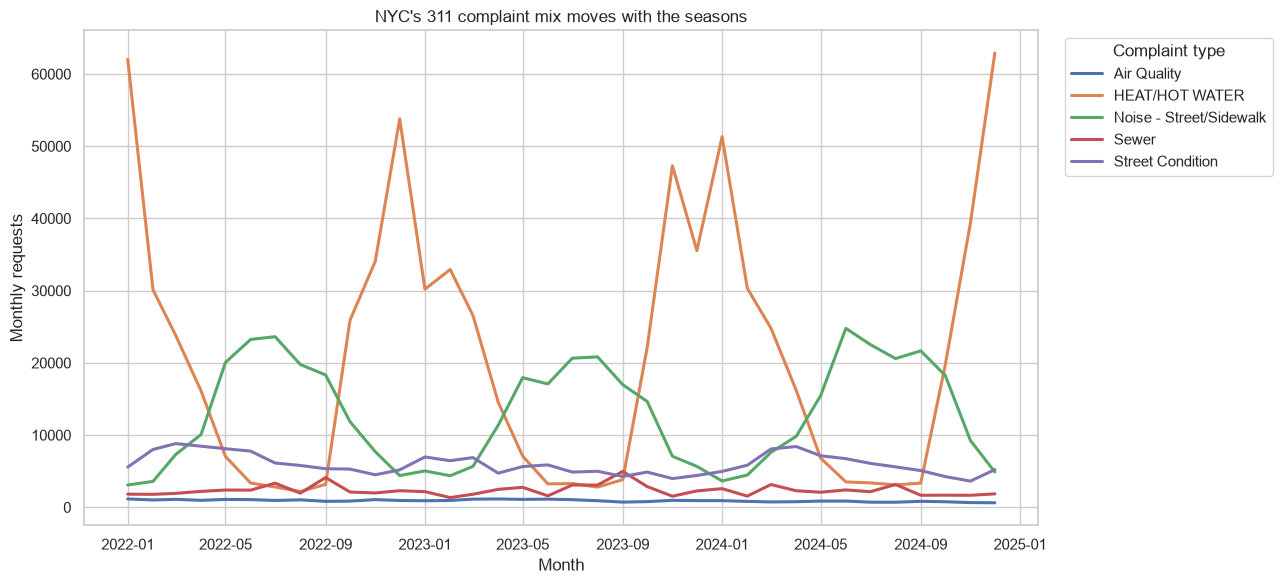

In [25]:
monthly_type = (
    daily_type.assign(month=daily_type["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "complaint_type"], as_index=False)["request_count"]
    .sum()
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=monthly_type,
    x="month",
    y="request_count",
    hue="complaint_type",
    linewidth=2.2,
    ax=ax,
)
ax.set(
    title="NYC's 311 complaint mix moves with the seasons",
    xlabel="Month",
    ylabel="Monthly requests",
)
ax.legend(title="Complaint type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_complaint_patterns.png", dpi=160, bbox_inches="tight")
plt.show()

**How to read:** Each line follows one complaint type month by month; peaks show when that issue becomes a larger burden on 311.  
**What it shows:** Heat and hot-water requests dominate the cold months, while street-noise requests rise sharply in warm weather. The repeated pattern across all three years suggests a stable seasonal relationship rather than a one-off event.

### Visual 2 — Temperature pushes two major complaint types in opposite directions

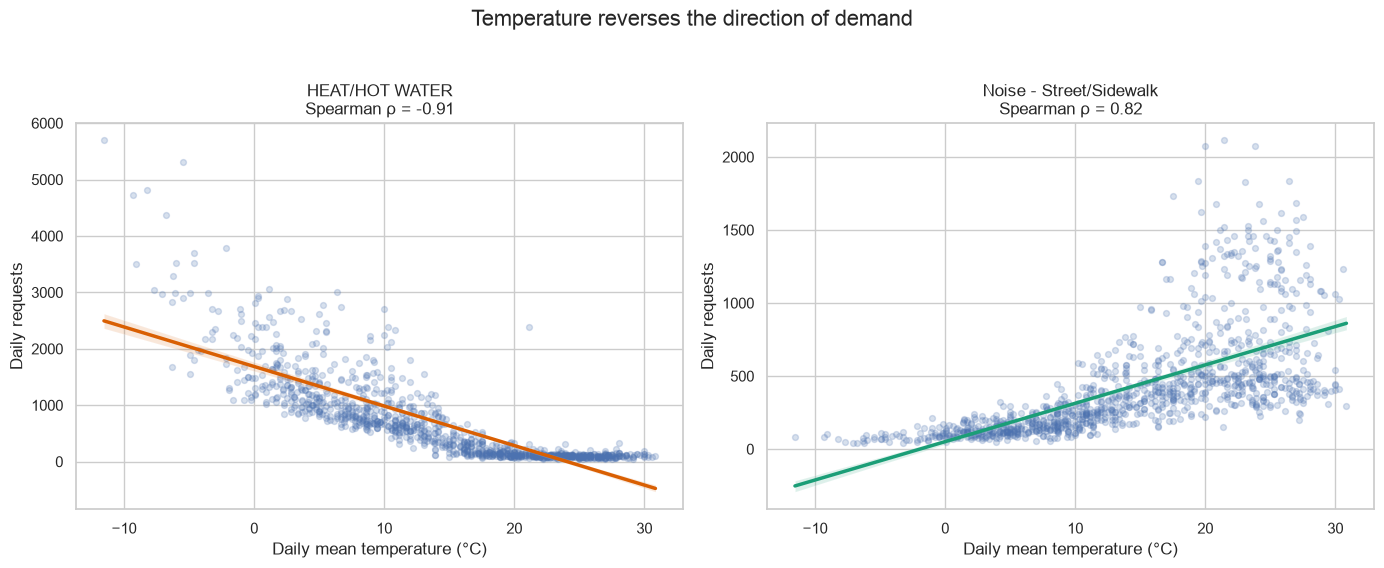

In [26]:
temperature_focus = daily_type[
    daily_type["complaint_type"].isin(["HEAT/HOT WATER", "Noise - Street/Sidewalk"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, complaint, color in zip(
    axes,
    ["HEAT/HOT WATER", "Noise - Street/Sidewalk"],
    ["#d95f02", "#1b9e77"],
):
    subset = temperature_focus[temperature_focus["complaint_type"].eq(complaint)]
    rho = correlations.loc[complaint]
    sns.regplot(
        data=subset,
        x="temp_mean_c",
        y="request_count",
        scatter_kws={"alpha": 0.22, "s": 18},
        line_kws={"color": color, "linewidth": 2.5},
        ax=ax,
    )
    ax.set(
        title=f"{complaint}\nSpearman ρ = {rho:.2f}",
        xlabel="Daily mean temperature (°C)",
        ylabel="Daily requests",
    )

fig.suptitle("Temperature reverses the direction of demand", y=1.03, fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "temperature_complaint_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

**How to read:** Every dot is one day; the fitted line summarizes the direction of the relationship, while Spearman's ρ measures its strength without assuming a perfectly linear pattern.  
**What it shows:** Heat and hot-water complaints have a very strong negative relationship with temperature (ρ = **−0.91**), while street-noise complaints have a strong positive relationship (ρ = **0.82**). Weather changes not only total demand but the type of help residents request.

### Visual 3 — Heavy rain is closely associated with sewer complaints

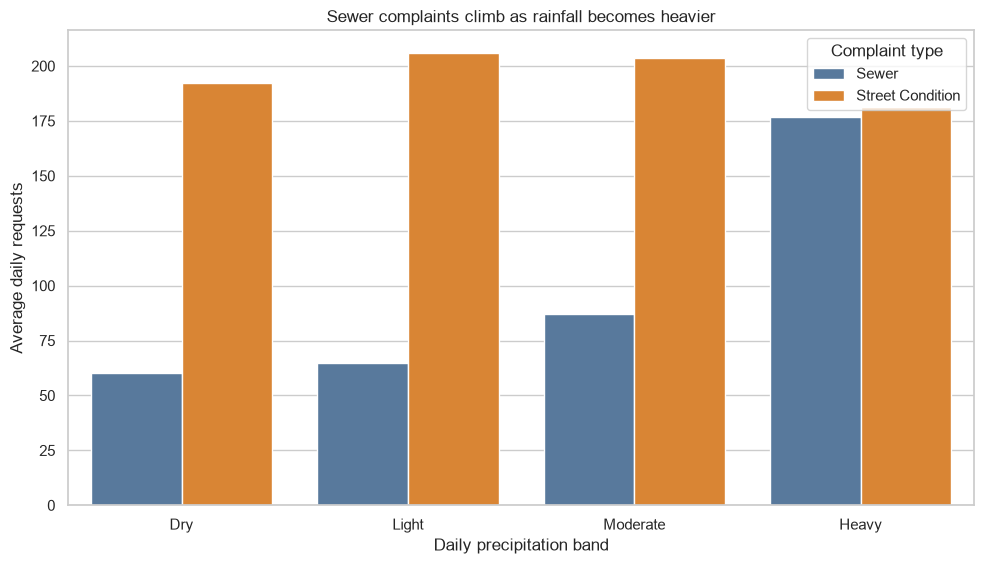

complaint_type,Sewer,Street Condition
rain_band,,
Dry,60.00,192.10
Light,64.60,205.90
Moderate,87.00,203.70
Heavy,176.60,181.40


In [27]:
rain_bins = [-0.01, 0, 2.5, 10, np.inf]
rain_labels = ["Dry", "Light", "Moderate", "Heavy"]
daily_type["rain_band"] = pd.cut(
    daily_type["prcp_mm"], bins=rain_bins, labels=rain_labels, include_lowest=True
)

rain_focus = (
    daily_type[daily_type["complaint_type"].isin(["Sewer", "Street Condition"])]
    .groupby(["rain_band", "complaint_type"], observed=True, as_index=False)["request_count"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5.8))
sns.barplot(
    data=rain_focus,
    x="rain_band",
    y="request_count",
    hue="complaint_type",
    palette=["#4c78a8", "#f58518"],
    ax=ax,
)
ax.set(
    title="Sewer complaints climb as rainfall becomes heavier",
    xlabel="Daily precipitation band",
    ylabel="Average daily requests",
)
ax.legend(title="Complaint type")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rainfall_infrastructure_complaints.png", dpi=160, bbox_inches="tight")
plt.show()

rain_table = rain_focus.pivot(index="rain_band", columns="complaint_type", values="request_count")
rain_table.round(1)

In [28]:
# Above the minimum: bootstrap the heavy-rain versus dry-day sewer ratio.
sewer_daily = daily_type[daily_type["complaint_type"].eq("Sewer")]
dry_sewer = sewer_daily.loc[sewer_daily["rain_band"].eq("Dry"), "request_count"].to_numpy()
heavy_sewer = sewer_daily.loc[sewer_daily["rain_band"].eq("Heavy"), "request_count"].to_numpy()

rng = np.random.default_rng(42)
bootstrap_ratios = np.array(
    [
        rng.choice(heavy_sewer, len(heavy_sewer), replace=True).mean()
        / rng.choice(dry_sewer, len(dry_sewer), replace=True).mean()
        for _ in range(5000)
    ]
)
observed_ratio = heavy_sewer.mean() / dry_sewer.mean()
ci_low, ci_high = np.quantile(bootstrap_ratios, [0.025, 0.975])
print(f"Heavy-rain / dry-day sewer ratio: {observed_ratio:.2f}x")
print(f"Bootstrap 95% interval: {ci_low:.2f}x to {ci_high:.2f}x")

Heavy-rain / dry-day sewer ratio: 2.94x
Bootstrap 95% interval: 2.37x to 3.71x


**How to read:** Bar height is the average number of requests on days in each rain band. The bootstrap interval repeats the comparison on resampled days to show how stable the heavy-rain effect is.  
**What it shows:** Heavy-rain days average **176.6 sewer requests**, compared with **60.0 on dry days**—about **2.9 times as many**. Street-condition complaints do not show the same monotonic rise, which makes the sewer response more specific and credible.

### Visual 4 — Every borough responds strongly to the cold

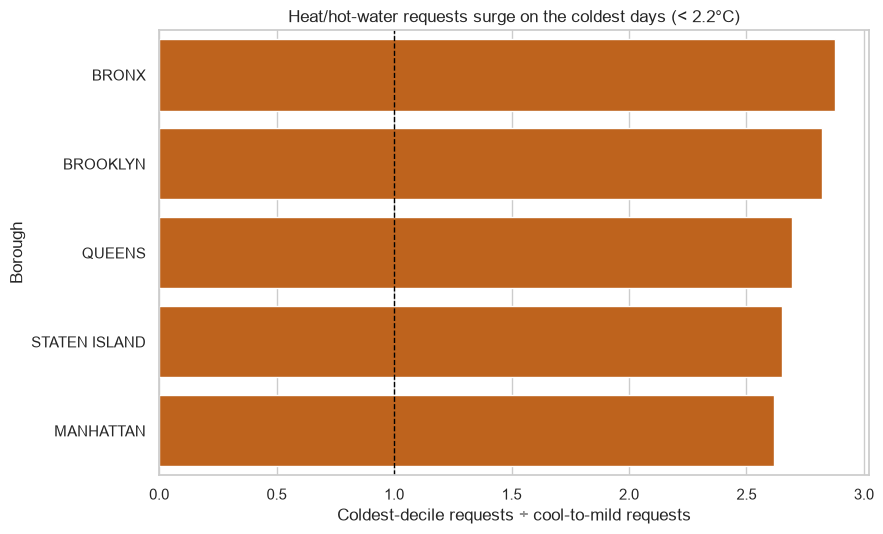

temperature_band,Coldest 10%,Cool to mild,Warm,cold_vs_mild_ratio
borough,,,,
BRONX,783.95,272.30,38.64,2.88
BROOKLYN,561.11,198.90,30.01,2.82
QUEENS,282.39,104.87,14.35,2.69
STATEN ISLAND,23.97,9.04,2.41,2.65
MANHATTAN,459.36,175.46,28.35,2.62


In [29]:
heat_borough = combined[combined["complaint_type"].eq("HEAT/HOT WATER")].copy()
daily_heat_borough = heat_borough.groupby(["date", "borough"], as_index=False).agg(
    request_count=("request_count", "sum"),
    temp_mean_c=("temp_mean_c", "first"),
)

cold_cutoff = weather_analysis["temp_mean_c"].quantile(0.10)
daily_heat_borough["temperature_band"] = pd.cut(
    daily_heat_borough["temp_mean_c"],
    bins=[-np.inf, cold_cutoff, 20, np.inf],
    labels=["Coldest 10%", "Cool to mild", "Warm"],
)

borough_response = daily_heat_borough.pivot_table(
    index="borough",
    columns="temperature_band",
    values="request_count",
    aggfunc="mean",
    observed=True,
)
borough_response["cold_vs_mild_ratio"] = (
    borough_response["Coldest 10%"] / borough_response["Cool to mild"]
)
borough_response = borough_response.sort_values("cold_vs_mild_ratio", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=borough_response.reset_index(),
    y="borough",
    x="cold_vs_mild_ratio",
    color="#d95f02",
    ax=ax,
)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set(
    title=f"Heat/hot-water requests surge on the coldest days (< {cold_cutoff:.1f}°C)",
    xlabel="Coldest-decile requests ÷ cool-to-mild requests",
    ylabel="Borough",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cold_weather_borough_response.png", dpi=160, bbox_inches="tight")
plt.show()

borough_response.round(2)

**How to read:** A value of 2 means the borough averages twice as many heat and hot-water complaints on the coldest 10% of days as on cool-to-mild days.  
**What it shows:** All five boroughs rise by roughly **2.6–2.9×**. The Bronx has both the largest relative increase (**2.88×**) and the highest average cold-day volume, pointing to a particularly heavy cold-weather service burden.

### Visual 5 — Seasonal composition, not just volume

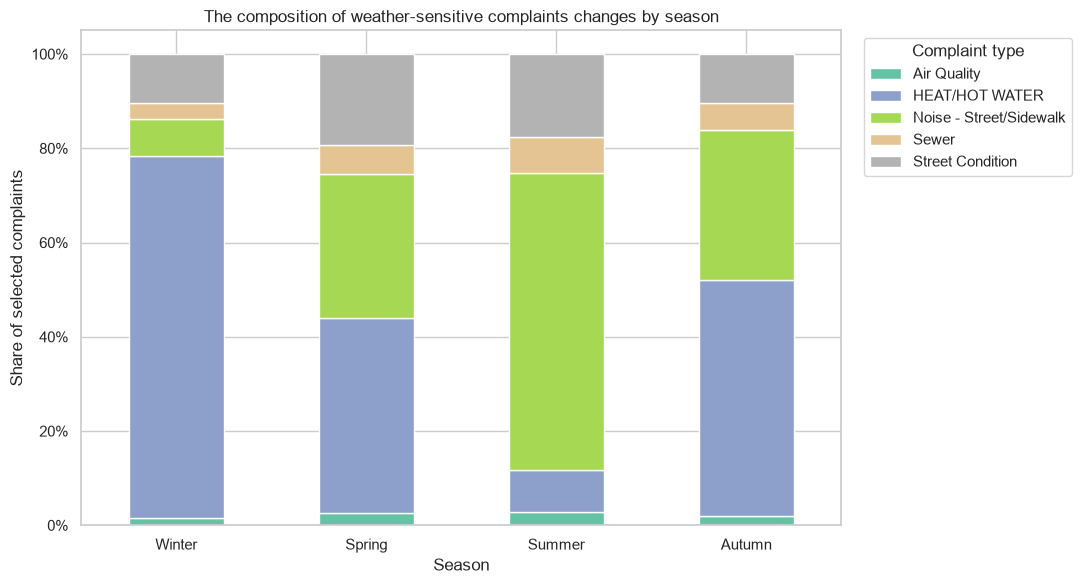

complaint_type,Air Quality,HEAT/HOT WATER,Noise - Street/Sidewalk,Sewer,Street Condition
season,,,,,
Winter,0.02,0.77,0.08,0.04,0.10
Spring,0.03,0.41,0.31,0.06,0.19
Summer,0.03,0.09,0.63,0.08,0.18
Autumn,0.02,0.50,0.32,0.06,0.10


In [30]:
season_lookup = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
season_order = ["Winter", "Spring", "Summer", "Autumn"]
seasonal_mix = (
    daily_type.assign(season=daily_type["date"].dt.month.map(season_lookup))
    .pivot_table(index="season", columns="complaint_type", values="request_count", aggfunc="sum")
    .reindex(season_order)
)
seasonal_share = seasonal_mix.div(seasonal_mix.sum(axis=1), axis=0)

ax = seasonal_share.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2",
)
ax.set(
    title="The composition of weather-sensitive complaints changes by season",
    xlabel="Season",
    ylabel="Share of selected complaints",
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="Complaint type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "seasonal_complaint_mix.png", dpi=160, bbox_inches="tight")
plt.show()

seasonal_share.round(3)

**How to read:** Each bar is one season and adds to 100%; wider colored sections represent a larger share of the five selected complaint types.  
**What it shows:** Heat and hot-water issues make up about **76.8%** of the selected winter complaints but only **9.0%** in summer. The seasonal shift reinforces that weather changes the composition of city service demand, not merely its total level.

### Answer

Weather has a large and highly specific relationship with NYC 311 demand. Colder days are strongly associated with heat and hot-water complaints, warmer days with street-noise complaints, and heavy rain with a nearly threefold increase in sewer complaints relative to dry days. The cold-weather response appears across all boroughs, but the Bronx carries the highest volume and strongest proportional increase, suggesting that weather preparedness and housing-service capacity should be planned geographically as well as seasonally.

These are observational relationships, not proof that weather alone caused every request. Still, the consistency across 1,096 days, multiple complaint types, and every borough makes the patterns useful for anticipating service pressure.

### 5.2 Reflection

With more time, I would add weather stations in the outer boroughs instead of using Central Park as the single citywide reference, and I would normalize borough complaint counts by population and housing stock. I would also compare reported complaints with agency response times and test lagged weather effects, since infrastructure failures and resident reporting may continue after the day of an extreme event. Those additions would make the geographic comparisons fairer and move the analysis closer to operational planning.

## Reproducibility notes

- The analysis window is fixed at 2022–2024 so results do not drift as live systems update.
- Both raw datasets and the cleaned combined dataset are stored separately.
- The NYC API query, cleaning decisions, validation checks, bootstrap seed, and chart code are all included.
- Source-specific flags and units are preserved or documented rather than silently discarded.